# Final Project: Next-Basket Recommendation from Retail Purchase History

## Main Question
Can time-ordered purchase patterns improve next-basket recommendation beyond popularity-based and basket-based methods?

## Extension
Can item embeddings improve a sequential recommender by reranking its candidate next items?

## Methods Compared
- Global popularity baseline
- Association-rule recommender
- Sequential recommender
- Hybrid sequential + embedding recommender

## Project Motivation

Retail transaction data contains several useful layers of structure. At the simplest level, it shows which products are purchased often. At a richer level, it shows which products tend to appear together in the same basket. It also shows the order in which customers make purchases over time. This project focuses on whether the time-ordered information could help us predict what a customer will buy next.

To answer this question, we compared a sequence of recommendation methods with increasing levels of structure, which include:
- A popularity baseline that uses only overall item frequency.
- An association-rule recommender that uses unordered basket structure.
- A sequential recommender that uses purchase order across time.
- A hybrid recommender that uses item embeddings to improve the sequential method by reranking its candidates.

The notebook is organized as one focused study. We first prepared the purchase-only data and defined a leakage-safe train-test setup. We then evaluated the three core recommenders on the same next-basket prediction task. After that, we explored the hybrid sequential-plus-embedding extension using the same evaluation setup. Finally, we compared all methods and used the results to answer the proposed research questions.

## Imports

We began by loading the packages needed throughout the project. Those packages included `pandas`, `numpy`, and `matplotlib.pyplot`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations, product
from collections import Counter, defaultdict

## Load the Raw Dataset

We first loaded the Online Retail dataset and inspected its structure using `pandas`.

From the output, we could see that the dataset has 541909 rows and 8 columns. Each row represents one purchased item, with fields including `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, and `Country`.

We could also find that one invoice might appear in multiple rows because of duplicated `InvoiceNo`. Because of that, we later need to preprocess the data so that invoices can be converted into basket-based transactions for recommendation and sequence analysis.

In [4]:
file_path = "Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Raw shape:", df.shape)
display(df.head())

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Define the Purchase-Only Data Pipeline

Since our analysis focuses on actual purchase behavior, we built a reusable preprocessing function to create a clean purchase-only dataset. In this function, we removed rows that would not make sense for recommendation, including **cancellations**, **non-positive quantities**, and **invalid prices**. We also dropped rows with missing key fields and stored important identifiers, such as `InvoiceNo` and `StockCode`, as strings for consistent processing later.

In [5]:
def load_purchase_only_data(file_path: str) -> pd.DataFrame:
    """
    Load the Online Retail dataset and keep purchase-only rows.

    Cleaning rules:
    - remove cancellations (InvoiceNo starts with 'C')
    - keep Quantity > 0
    - keep UnitPrice > 0
    - drop missing InvoiceNo, StockCode, InvoiceDate
    - cast InvoiceNo and StockCode to string
    """
    df = pd.read_excel(file_path)

    df["InvoiceNo"] = df["InvoiceNo"].astype(str)
    df["StockCode"] = df["StockCode"].astype(str)

    is_cancellation = df["InvoiceNo"].str.startswith("C", na=False)

    df_purchase = df.loc[~is_cancellation].copy()
    df_purchase = df_purchase.loc[df_purchase["Quantity"] > 0].copy()
    df_purchase = df_purchase.loc[df_purchase["UnitPrice"] > 0].copy()
    df_purchase = df_purchase.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate"]).copy()
    df_purchase = df_purchase.loc[df_purchase["StockCode"].str.strip() != ""].copy()

    df_purchase["InvoiceDate"] = pd.to_datetime(df_purchase["InvoiceDate"], errors="coerce")
    df_purchase = df_purchase.dropna(subset=["InvoiceDate"]).copy()

    return df_purchase

## Apply Preprocessing and Check the Working Dataset

After cleaning the raw data, we checked the size and time range of the purchase-only dataset.

From the summary, we could see that the cleaned dataset still contains 530104 rows, which means that most of the original data was kept. These rows contains 19960 unique invoices, 3922 unique items, and 4339 unique customers. The date range runs from early December 2010 to early December 2011, which covers one full year of purchase history. All these numbers shows that even after cleaning, the dataset still provides enough invoices to build baskets, enough customers to form purchase histories, and enough time span to study next-basket behavior.

In [6]:
df_purchase = load_purchase_only_data(file_path)

print("Purchase-only shape:", df_purchase.shape)
print("Unique invoices:", df_purchase["InvoiceNo"].nunique())
print("Unique items:", df_purchase["StockCode"].nunique())
print("Unique customers:", df_purchase["CustomerID"].nunique())
print("Date range:", df_purchase["InvoiceDate"].min(), "to", df_purchase["InvoiceDate"].max())

Purchase-only shape: (530104, 8)
Unique invoices: 19960
Unique items: 3922
Unique customers: 4338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


## Build a Product Description Lookup

Because the item description could help the intepretation in some later parts of the notebook, we built a reusable lookup from `StockCode` to a representative product description. In the code below, we removed missing descriptions, cleaned the text, and then kept the most common description for each item code.

From the output, we can see that all 3922 items in the cleaned dataset have their corresponding descriptions in the lookup table.

In [7]:
def build_description_map(df_purchase: pd.DataFrame) -> pd.Series:
    """
    Build a representative description for each StockCode.

    Parameters
    ----------
    df_purchase : pd.DataFrame
        Purchase-only transaction data containing at least
        'StockCode' and 'Description'.

    Returns
    -------
    pd.Series
        Index is StockCode and value is the most common cleaned description.
    """
    return (
        df_purchase[["StockCode", "Description"]]
        .dropna()
        .assign(
            StockCode=lambda x: x["StockCode"].astype(str),
            Description=lambda x: x["Description"].astype(str).str.strip()
        )
        .groupby("StockCode")["Description"]
        .agg(lambda x: x.value_counts().index[0])
    )

desc_map = build_description_map(df_purchase)

print("Number of items with descriptions:", len(desc_map))
display(desc_map.head(10).to_frame(name="Description"))

Number of items with descriptions: 3922


,Description
StockCode,
10002,INFLATABLE POLITICAL GLOBE
10080,GROOVY CACTUS INFLATABLE
10120,DOGGY RUBBER
10123C,HEARTS WRAPPING TAPE
10124A,SPOTS ON RED BOOKCOVER TAPE
10124G,ARMY CAMO BOOKCOVER TAPE
10125,MINI FUNKY DESIGN TAPES
10133,COLOURING PENCILS BROWN TUBE
10135,COLOURING PENCILS BROWN TUBE


## Create Basket and Invoice Tables

To support both basket-based and sequence-based methods, we split the cleaned transaction data into two reusable tables. The first table, `invoice_item`, keeps one row for each unique `(InvoiceNo, StockCode)` pair. This table offers a basket view of the data, where repeated copies of the same item inside one invoice do not create duplicate entries. The second table, `invoice_meta`, keeps one row per invoice with the customer ID, invoice time, and country, which provides the information needed to place each basket in customer purchase history.

From the output, we could see that `invoice_item` contains 519602 invoice-item pairs. On the other hand, `invoice_meta` contains 18532 invoices with valid customer IDs, where we could find some purchase rows were excluded because they could not be tied to a customer.

In [8]:
def build_invoice_tables(df_purchase: pd.DataFrame):
    """
    Build:
    - invoice_item: one row per (InvoiceNo, StockCode)
    - invoice_meta: one row per InvoiceNo with customer and timestamp
    """
    invoice_item = (
        df_purchase[["InvoiceNo", "StockCode"]]
        .drop_duplicates()
        .copy()
    )

    invoice_meta = (
        df_purchase[["InvoiceNo", "CustomerID", "InvoiceDate", "Country"]]
        .drop_duplicates(subset=["InvoiceNo"])
        .copy()
    )

    invoice_meta = invoice_meta.dropna(subset=["CustomerID"]).copy()
    invoice_meta["CustomerID"] = invoice_meta["CustomerID"].astype(str)

    return invoice_item, invoice_meta


invoice_item, invoice_meta = build_invoice_tables(df_purchase)

print("invoice_item shape:", invoice_item.shape)
print("invoice_meta shape:", invoice_meta.shape)
display(invoice_item.head())
display(invoice_meta.head())

invoice_item shape: (519602, 2)
invoice_meta shape: (18532, 4)


,InvoiceNo,StockCode
0,536365,85123A
1,536365,71053
2,536365,84406B
3,536365,84029G
4,536365,84029E


,InvoiceNo,CustomerID,InvoiceDate,Country
0,536365,17850.0,2010-12-01 08:26:00,United Kingdom
7,536366,17850.0,2010-12-01 08:28:00,United Kingdom
9,536367,13047.0,2010-12-01 08:34:00,United Kingdom
21,536368,13047.0,2010-12-01 08:34:00,United Kingdom
25,536369,13047.0,2010-12-01 08:35:00,United Kingdom


## Build Ordered Customer Purchase Histories

Next, we converted the invoice-level data into customer-level purchase histories. Each invoice becomes one basket of unique items, and each customer becomes an ordered list of baskets over time. They are the main input for the sequential recommender because they contain the information of each basket and the order in which those baskets happened.

From the output, we could see that the cleaned data produced 18532 invoice baskets across 4338 customers. Each row of `invoice_baskets` now represents one customer purchase event with its timestamp and list of items, instead of one row per line item as in the raw data. The `customer_sequences` object then groups those baskets by customer, where each customer is represented by a full ordered purchase history.

In [9]:
def build_customer_sequences(invoice_item: pd.DataFrame, invoice_meta: pd.DataFrame):
    """
    Build ordered customer purchase sequences.

    Returns
    -------
    invoice_baskets : DataFrame
        One row per invoice with customer, date, and basket_items.
    customer_sequences : Series
        Indexed by CustomerID, each value is a list of baskets in time order.
    """
    invoice_baskets = (
        invoice_item.merge(invoice_meta, on="InvoiceNo", how="inner")
        .groupby(["CustomerID", "InvoiceDate", "InvoiceNo", "Country"])["StockCode"]
        .apply(lambda s: sorted(set(s)))
        .reset_index(name="basket_items")
        .sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
        .reset_index(drop=True)
    )

    customer_sequences = (
        invoice_baskets.groupby("CustomerID")["basket_items"]
        .apply(list)
    )

    return invoice_baskets, customer_sequences


invoice_baskets, customer_sequences = build_customer_sequences(invoice_item, invoice_meta)

print("Number of invoice baskets:", len(invoice_baskets))
print("Number of customers with sequences:", len(customer_sequences))
display(invoice_baskets.head())
display(customer_sequences.head())

Number of invoice baskets: 18532
Number of customers with sequences: 4338


,CustomerID,InvoiceDate,InvoiceNo,Country,basket_items
0,12346.0,2011-01-18 10:01:00,541431,United Kingdom,[23166]
1,12347.0,2010-12-07 14:57:00,537626,Iceland,"[20780, 20782, 21064, 21171, 21731, 22195, 222..."
2,12347.0,2011-01-26 14:30:00,542237,Iceland,"[20719, 20966, 21035, 21041, 21154, 21731, 218..."
3,12347.0,2011-04-07 10:43:00,549222,Iceland,"[16008, 20665, 21041, 21731, 21791, 21975, 221..."
4,12347.0,2011-06-09 13:01:00,556201,Iceland,"[17021, 22196, 22371, 22375, 22725, 22727, 230..."


,basket_items
CustomerID,
12346.0,[[23166]]
12347.0,"[[20780, 20782, 21064, 21171, 21731, 22195, 22..."
12348.0,"[[21211, 21213, 21725, 21977, 21981, 21982, 22..."
12349.0,"[[20685, 20914, 21086, 21136, 21231, 21232, 21..."
12350.0,"[[20615, 20652, 21171, 21832, 21864, 21866, 21..."


## Define a Next-Basket Prediction Setup

To evaluate the recommendation methods fairly, we used a last-basket holdout design. We kept customers with at least 3 invoices because we need enough history to form a purchase sequence for the prediction. For each customer, all earlier baskets were used as training data and the final basket was held out as the test case. Here, we used only the final basket as the testing basket because at the customer level, it could avoid mixing multiple test targets from the same customer. Since later we would compare all recommenders, this setup could also help keep the comparison consistent.

In [10]:
def build_last_basket_holdout(invoice_baskets: pd.DataFrame, min_invoices: int = 3):
    """
    Build a last-basket holdout split.

    For each customer with at least `min_invoices`:
    - train history = all but last basket
    - test basket = last basket

    Returns
    -------
    train_baskets : DataFrame
    test_baskets : DataFrame
    eligible_customers : list
    """
    counts = invoice_baskets.groupby("CustomerID")["InvoiceNo"].nunique()
    eligible_customers = counts[counts >= min_invoices].index.tolist()

    eligible = invoice_baskets.loc[invoice_baskets["CustomerID"].isin(eligible_customers)].copy()
    eligible = eligible.sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"]).copy()

    eligible["basket_order"] = eligible.groupby("CustomerID").cumcount()
    eligible["n_baskets"] = eligible.groupby("CustomerID")["InvoiceNo"].transform("count")

    train_baskets = eligible.loc[eligible["basket_order"] < eligible["n_baskets"] - 1].copy()
    test_baskets = eligible.loc[eligible["basket_order"] == eligible["n_baskets"] - 1].copy()

    return train_baskets, test_baskets, eligible_customers

## Build the Train-Test Split

We now applied the last-basket holdout design and then inspected the resulting train and test sets.

From the output, we could see that 2010 customers had at least 3 invoices and were therefore, included in the evaluation. Their earlier purchase history produced 13359 training baskets, while their most recent purchase formed 2010 testing baskets.

From the exmaple rows, we could see the split worked as intended. For example, for customer `12347.0`, several earlier basket appear in the training set, while the last observed basket appears in the test set.

In [11]:
train_baskets, test_baskets, eligible_customers = build_last_basket_holdout(
    invoice_baskets=invoice_baskets,
    min_invoices=3
)

print("Eligible customers:", len(eligible_customers))
print("Train baskets:", len(train_baskets))
print("Test baskets:", len(test_baskets))

display(train_baskets.head())
display(test_baskets.head())

Eligible customers: 2010
Train baskets: 13359
Test baskets: 2010


,CustomerID,InvoiceDate,InvoiceNo,Country,basket_items,basket_order,n_baskets
1,12347.0,2010-12-07 14:57:00,537626,Iceland,"[20780, 20782, 21064, 21171, 21731, 22195, 222...",0,7
2,12347.0,2011-01-26 14:30:00,542237,Iceland,"[20719, 20966, 21035, 21041, 21154, 21731, 218...",1,7
3,12347.0,2011-04-07 10:43:00,549222,Iceland,"[16008, 20665, 21041, 21731, 21791, 21975, 221...",2,7
4,12347.0,2011-06-09 13:01:00,556201,Iceland,"[17021, 22196, 22371, 22375, 22725, 22727, 230...",3,7
5,12347.0,2011-08-02 08:48:00,562032,Iceland,"[20719, 21578, 21791, 21975, 22371, 22372, 223...",4,7


,CustomerID,InvoiceDate,InvoiceNo,Country,basket_items,basket_order,n_baskets
7,12347.0,2011-12-07 15:52:00,581180,Iceland,"[20719, 21064, 21265, 21731, 23084, 23271, 234...",6,7
11,12348.0,2011-09-25 13:13:00,568172,Finland,"[23077, 23078, POST]",3,4
21,12352.0,2011-11-03 14:37:00,574275,Norway,"[21669, 22178, 22624, 22627, 22635, 22668, 229...",7,8
27,12356.0,2011-11-17 08:40:00,576895,Portugal,"[21843, 22423]",2,3
34,12359.0,2011-10-13 12:47:00,571034,Cyprus,"[20751, 21116, 21136, 21166, 21523, 21528, 217...",3,4


## Validate the Train-Test Split

Before building recommenders, we ran a few checks to confirm that the split is valid. In particular, each customer should have exactly one held-out test basket, train and test baskets must not overlap, and all training baskets must occur before the test basket in time.

In [12]:
def test_last_basket_holdout(train_baskets: pd.DataFrame, test_baskets: pd.DataFrame):
    # Each eligible customer should have exactly one test basket
    test_counts = test_baskets.groupby("CustomerID")["InvoiceNo"].nunique()
    assert (test_counts == 1).all()

    # No customer should have overlap between train and test invoices
    train_pairs = set(zip(train_baskets["CustomerID"], train_baskets["InvoiceNo"]))
    test_pairs = set(zip(test_baskets["CustomerID"], test_baskets["InvoiceNo"]))
    assert train_pairs.isdisjoint(test_pairs)

    # Every train basket should happen before the test basket
    merged = (
        train_baskets.groupby("CustomerID")["InvoiceDate"].max().rename("last_train_date").reset_index()
        .merge(
            test_baskets[["CustomerID", "InvoiceDate"]].rename(columns={"InvoiceDate": "test_date"}),
            on="CustomerID",
            how="inner"
        )
    )
    assert (merged["last_train_date"] <= merged["test_date"]).all()

    print("All train-test split checks passed.")


test_last_basket_holdout(train_baskets, test_baskets)

All train-test split checks passed.


At this point, we had a clean purchase-only dataset, a basket representation for association-rule mining, a sequence representation for time-ordered analysis, and a leakage-safe evaluation split. With this foundation in place, we could now begin with the simplest recommender: a global popularity baseline.

## Global Popularity Baseline Recommender

We began with the simplest possible recommender: a global popularity baseline. This method ignores customer-specific history and recommends the most frequently purchased items from the training data. Although simple, it is an important benchmark because it tells us how much predictive power comes from item popularity alone.

If more complex methods cannot beat this baseline, then their added structure may not be helping in a meaningful way.

### Learn Item Popularity from the Training Data

We began by computing item popularity using only the training baskets. Specifically, we counted how often each item appears in training invoices across all baskets and then ranked items from most frequent to least frequent.

In [13]:
def fit_popularity_recommender(train_baskets: pd.DataFrame) -> pd.DataFrame:
    """
    Fit a global popularity recommender from training baskets.

    Parameters
    ----------
    train_baskets : pd.DataFrame
        Must contain a column 'basket_items', where each row is a list of unique items
        in one training invoice.

    Returns
    -------
    popularity_df : pd.DataFrame
        Columns:
        - StockCode
        - train_invoice_count
        - popularity_rank
    """
    item_counts = Counter()

    for basket in train_baskets["basket_items"]:
        for item in basket:
            item_counts[item] += 1

    popularity_df = (
        pd.DataFrame({
            "StockCode": list(item_counts.keys()),
            "train_invoice_count": list(item_counts.values())
        })
        .sort_values(["train_invoice_count", "StockCode"], ascending=[False, True])
        .reset_index(drop=True)
    )

    popularity_df["popularity_rank"] = np.arange(1, len(popularity_df) + 1)
    return popularity_df

In [50]:
popularity_df = fit_popularity_recommender(train_baskets).copy()

### Inspect the Most Popular Training Items

Before generating recommendations, we inspected the most popular items learned from the training set and attached product descriptions for better readability. Since the popularity model uses only item frequency, the most highly ranked products would reflect broad purchase frequency across all baskets.

From the output, we can see that the popularity baseline was dominated by a small group of widely purchased products, including home decor items, lunch bags, party products, and shipping-related entries such as **POSTAGE**. Since these are items that appeared often across many training invoices, they became the default recommendations for every customer.

In [51]:
popularity_df["Description"] = popularity_df["StockCode"].map(desc_map)

print("Number of recommendable items:", len(popularity_df))
display(
    popularity_df[
        ["popularity_rank", "StockCode", "Description", "train_invoice_count"]
    ].head(20)
)

Number of recommendable items: 3580


,popularity_rank,StockCode,Description,train_invoice_count
0,1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1497
1,2,85099B,JUMBO BAG RED RETROSPOT,1280
2,3,22423,REGENCY CAKESTAND 3 TIER,1255
3,4,20725,LUNCH BAG RED RETROSPOT,1086
4,5,47566,PARTY BUNTING,1074
5,6,84879,ASSORTED COLOUR BIRD ORNAMENT,971
6,7,20727,LUNCH BAG BLACK SKULL.,857
7,8,22383,LUNCH BAG SUKI DESIGN,849
8,9,22720,SET OF 3 CAKE TINS PANTRY DESIGN,841
9,10,23203,JUMBO BAG VINTAGE DOILY,839


### Define How the Baseline Makes Recommendations

For each customer, the popularity baseline simply recommends the top-k (with default 5) most popular items from the training data. To avoid trivial repetition, we excluded items that already appear in the customer's most recent observed training basket. This exclusion could prevent the model from simply echoing the current basket and makes the task closer to true next-basket prediction.

In [15]:
def recommend_popular_items(
    popularity_df: pd.DataFrame,
    recent_basket: list,
    k: int = 5,
) -> list:
    """
    Recommend the top-k globally popular items not already in the recent basket.

    Parameters
    ----------
    popularity_df : pd.DataFrame
        Output of fit_popularity_recommender().
    recent_basket : list
        Items in the customer's most recent training basket.
    k : int, default=5
        Number of items to recommend.

    Returns
    -------
    list
        Top-k recommended StockCodes.
    """
    recent_set = set(recent_basket)

    recs = [
        item for item in popularity_df["StockCode"]
        if item not in recent_set
    ]

    return recs[:k]

### Generate Popularity-Based Recommendations for the Test Customers

We now applied the popularity baseline to each eligible customer. We first found each customer's most recent basket in the training set by sorting the training baskets by customer, date, and invoice number, and then we took the last basket for each customer. We then took the held-out basket from the test set, which is the basket we want the recommender to predict. After that, we merged these two pieces together by CustomerID, so that each row contains one customer's recent training basket and that customer's true next basket. We then applied the popularity recommender to the recent basket and generated the top-k recommended items.

In [16]:
def build_popularity_predictions(
    train_baskets: pd.DataFrame,
    test_baskets: pd.DataFrame,
    popularity_df: pd.DataFrame,
    k: int = 5,
) -> pd.DataFrame:
    """
    Build customer-level popularity recommendations for evaluation.

    Parameters
    ----------
    train_baskets : pd.DataFrame
        Training baskets with at least:
        - CustomerID
        - InvoiceDate
        - InvoiceNo
        - basket_items
    test_baskets : pd.DataFrame
        Test baskets with at least:
        - CustomerID
        - basket_items
    popularity_df : pd.DataFrame
        Output of fit_popularity_recommender().
    k : int, default=5
        Number of recommendations.

    Returns
    -------
    pred_df : pd.DataFrame
        One row per test customer with:
        - CustomerID
        - recent_basket
        - true_next_basket
        - recommendations
    """
    recent_train = (
        train_baskets.sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
        .groupby("CustomerID")
        .tail(1)
        .loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "recent_basket"})
    )

    truth = (
        test_baskets.loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "true_next_basket"})
        .copy()
    )

    pred_df = recent_train.merge(truth, on="CustomerID", how="inner")

    pred_df["recommendations"] = pred_df["recent_basket"].apply(
        lambda basket: recommend_popular_items(popularity_df, basket, k=k)
    )

    return pred_df

In [48]:
pop_pred_5 = build_popularity_predictions(
    train_baskets=train_baskets,
    test_baskets=test_baskets,
    popularity_df=popularity_df,
    k=5,
)

### Define Recommendation Metrics

To evaluate the baseline fairly, we used standard next-basket recommendation metrics. We went through each customer-level prediction, compared the recommended items with the true held-out next basket, and stores the result for four different metrics.

Each metric captures a different part of recommendation quality. **Hit Rate@k** checks whether at least one recommended item appears in the true next basket. **Recall@k** measures how much of the next basket we recover. **Precision@k** measures how many of the recommended items are correct and **Coverage** measures how often the method is able to return any recommendations. In the code, this was done by turning the true next basket and the recommendation list into sets, computing their overlap, and then summarizing the results across all test customers.

In [17]:
def evaluate_recommendations(pred_df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    """
    Evaluate next-basket recommendations.

    Parameters
    ----------
    pred_df : pd.DataFrame
        Must contain:
        - true_next_basket
        - recommendations
    k : int, default=5
        Recommendation cutoff.

    Returns
    -------
    pd.DataFrame
        One-row summary with HitRate@k, Recall@k, Precision@k, Coverage.
    """
    hits = []
    recalls = []
    precisions = []
    coverages = []

    for _, row in pred_df.iterrows():
        true_set = set(row["true_next_basket"])
        recs = row["recommendations"][:k]
        rec_set = set(recs)

        overlap = true_set & rec_set

        hit = int(len(overlap) > 0)
        recall = len(overlap) / len(true_set) if len(true_set) > 0 else np.nan
        precision = len(overlap) / k if k > 0 else np.nan
        coverage = int(len(recs) > 0)

        hits.append(hit)
        recalls.append(recall)
        precisions.append(precision)
        coverages.append(coverage)

    return pd.DataFrame({
        f"HitRate@{k}": [np.mean(hits)],
        f"Recall@{k}": [np.nanmean(recalls)],
        f"Precision@{k}": [np.nanmean(precisions)],
        "Coverage": [np.mean(coverages)],
        "n_test_customers": [len(pred_df)],
    })

### Evaluate the Popularity Baseline

We now evaluated the Popularity baseline by using the metrices we defined. These results would serve as the baseline that the association-rule recommender and the sequential recommender must beat.

In [49]:
pop_eval_5 = evaluate_recommendations(pop_pred_5, k=5)

display(pop_eval_5)
display(pop_pred_5.head(10))

,HitRate@5,Recall@5,Precision@5,Coverage,n_test_customers
0,0.185572,0.012945,0.04398,1.0,2010


,CustomerID,recent_basket,true_next_basket,recommendations
0,12347.0,"[20719, 21265, 21636, 21731, 21791, 21976, 221...","[20719, 21064, 21265, 21731, 23084, 23271, 234...","[85123A, 85099B, 20725, 47566, 84879]"
1,12348.0,"[22437, 23076, 23077, 23078, POST]","[23077, 23078, POST]","[85123A, 85099B, 22423, 20725, 47566]"
2,12352.0,"[21731, 21755, 21756, 21770, 22550, 22634, 226...","[21669, 22178, 22624, 22627, 22635, 22668, 229...","[85123A, 85099B, 22423, 20725, 47566]"
3,12356.0,"[20971, 21080, 21086, 21094, 21122, 21124, 211...","[21843, 22423]","[85123A, 85099B, 20725, 47566, 84879]"
4,12359.0,"[21260, 21277, 21770, 21843, 21906, 22109, 223...","[20751, 21116, 21136, 21166, 21523, 21528, 217...","[85123A, 85099B, 20725, 47566, 84879]"
5,12360.0,"[20674, 20675, 20676, 20677, 20713, 21242, 212...","[20676, 20682, 20686, 20749, 20750, 20978, 211...","[85123A, 85099B, 22423, 20725, 47566]"
6,12362.0,"[21484, 22197, 22659, 22812, 22900, 22962, 229...","[20749, 20750, 21704, 21931, 22328, 22549, 228...","[85123A, 85099B, 22423, 20725, 47566]"
7,12364.0,"[21058, 21059, 21060, 21062, 21063, 21080, 210...","[16156L, 16156S, 16161U, 16169M, 21126, 21197,...","[85123A, 85099B, 22423, 20725, 47566]"
8,12370.0,"[18097C, 20653, 20654, 20658, 20967, 20969, 20...","[18097C, 20969, 20970, 21808, 22153, 22154, 22...","[85123A, 85099B, 22423, 20725, 47566]"
9,12372.0,"[16156L, 16156S, 16161U, 20750, 22045, 22138, ...","[22326, 22374, 22550, 22551, 22555, 22556, 226...","[85123A, 85099B, 22423, 20725, 47566]"


### Results and Interpretation

From the results, we could see that the global popularity baseline gave us a useful lower bar for the recommendation task. At **k = 5**, it achieved a **Hit Rate of 0.186**, which means it placed at least one correct item in the recommendation list for about 18.6% of test customers. However, its **Recall@5 is only 0.013** and its **Precision@5 is 0.044**, which shows that most recommended items did not match the held-out next basket. Coverage is **1.0** because the method can always return popular items.

The example predictions helped explain these results. We could find that the baseline recommended the same small set of very common products to nearly every customer, regardless of their recent basket. This makes the method broadly available, but not very personalized. In some cases it might hit a frequent item that appears again later, but it often missed the more specific products that actually appear in the next basket.

### Validate the Baseline Logic

Before moving on, we ran a few checks to confirm that the baseline behaves correctly. In particular, recommendations should exclude items from the recent basket, return at most k items, and produce one prediction per test customer.

In [19]:
def test_popularity_baseline(
    popularity_df: pd.DataFrame,
    pop_pred: pd.DataFrame,
    k: int = 5,
):
    # One prediction per test customer
    assert pop_pred["CustomerID"].nunique() == len(pop_pred)

    # Recommendations should have length <= k
    assert pop_pred["recommendations"].apply(len).le(k).all()

    # Recommendations should exclude items from recent basket
    assert pop_pred.apply(
        lambda row: set(row["recommendations"]).isdisjoint(set(row["recent_basket"])),
        axis=1
    ).all()

    # Popularity table should be sorted descending
    counts = popularity_df["train_invoice_count"].values
    assert np.all(counts[:-1] >= counts[1:])

    print("All popularity baseline checks passed.")


test_popularity_baseline(popularity_df, pop_pred_5, k=5)

All popularity baseline checks passed.


## Association-Rule Recommender

The popularity baseline ignored basket structure and recommended the same globally frequent items to everyone. We now moved to a more informative method: an association-rule recommender. This approach uses co-purchase structure in the training baskets to learn which items tend to appear together, and then recommends items that are strongly associated with the customer's most recent basket.

Since this method does not use purchase order across time,  it is still based on unordered baskets. However, it is still a useful middle point in the project because if it improves over popularity, then proves that basket structure could be helpful for recommendation, and if the sequential recommender improves further, then time order adds extra value beyond co-purchase alone.

### Mine Frequent Basket Patterns from the Training Data

We began by mining frequent itemsets from the training baskets only. We used Aprori by first turning the basket column into a list of baskets, computing the total number of baskets, and converting the minimum support threshold into a minimum support count. We then counted how often single items appear, kept only the items that meet the support threshold, and stored both their support counts and support values. After that, we repeated the same idea for item pairs. For triples, we added one more pruning step by only counting triples if all of its two-item subsets were already frequent.

We limited the search to itemsets of size 1, 2, and 3 for both practical and interpretive reasons. Larger itemsets would increase the number of candidates quickly and would also be harder to explain later in the notebook. In contrast, itemsets of size 1, 2, and 3 are enough to support clear association rules while keeping the results manageable.

In [20]:
def mine_frequent_itemsets_small(
    train_baskets: pd.DataFrame,
    min_support: float = 0.01,
    max_k: int = 3,
) -> tuple[pd.DataFrame, dict]:
    """
    Mine frequent itemsets of size 1, 2, and 3 from training baskets.

    Parameters
    ----------
    train_baskets : pd.DataFrame
        Must contain column 'basket_items', where each row is a list of unique items.
    min_support : float, default=0.01
        Minimum support threshold as a fraction of baskets.
    max_k : int, default=3
        Maximum itemset size to consider.

    Returns
    -------
    itemsets_df : pd.DataFrame
        Columns:
        - k
        - itemset
        - support_count
        - support
    support_lookup : dict
        Maps tuple(itemset) -> support_count
    """
    baskets = train_baskets["basket_items"].tolist()
    n_baskets = len(baskets)
    min_count = int(np.ceil(min_support * n_baskets))

    support_lookup = {}
    rows = []

    # 1-itemsets
    item_counts = Counter()
    for basket in baskets:
        for item in basket:
            item_counts[item] += 1

    L1 = {tuple([item]): cnt for item, cnt in item_counts.items() if cnt >= min_count}
    for itemset, cnt in L1.items():
        support_lookup[itemset] = cnt
        rows.append({
            "k": 1,
            "itemset": itemset,
            "support_count": cnt,
            "support": cnt / n_baskets,
        })

    if max_k >= 2:
        frequent_items = sorted([x[0] for x in L1.keys()])
        frequent_item_set = set(frequent_items)

        pair_counts = Counter()
        for basket in baskets:
            filtered = sorted([x for x in basket if x in frequent_item_set])
            for pair in combinations(filtered, 2):
                pair_counts[pair] += 1

        L2 = {pair: cnt for pair, cnt in pair_counts.items() if cnt >= min_count}
        for itemset, cnt in L2.items():
            support_lookup[itemset] = cnt
            rows.append({
                "k": 2,
                "itemset": itemset,
                "support_count": cnt,
                "support": cnt / n_baskets,
            })
    else:
        L2 = {}

    if max_k >= 3 and L2:
        pair_set = set(L2.keys())
        triple_counts = Counter()

        for basket in baskets:
            filtered = sorted([x for x in basket if (x,) in L1])
            for triple in combinations(filtered, 3):
                if all(tuple(sorted(p)) in pair_set for p in combinations(triple, 2)):
                    triple_counts[triple] += 1

        L3 = {triple: cnt for triple, cnt in triple_counts.items() if cnt >= min_count}
        for itemset, cnt in L3.items():
            support_lookup[itemset] = cnt
            rows.append({
                "k": 3,
                "itemset": itemset,
                "support_count": cnt,
                "support": cnt / n_baskets,
            })

    itemsets_df = pd.DataFrame(rows).sort_values(
        ["k", "support_count"], ascending=[True, False]
    ).reset_index(drop=True)

    return itemsets_df, support_lookup

### Inspect the Frequent Itemsets

Before generating association rules, we inspected the frequent itemsets mined from the training baskets. To make the output easier to read, we attached product descriptions to each itemset so that the reviewer can see the actual products instead of only raw stock codes.

From the output, we could see that the training data produced 1194 frequent itemsets, with 622 single items, 426 item pairs, and 146 item triples. The most common itemsets at the top of the table are still single items, which is expected because single items usually appear more often than larger combinations. Many of the top 1-itemsets are familiar products that already appeared in the popularity baseline, such as lunch bags, jumbo bags, party products, and decorative household items.

In [21]:
def format_itemset_with_descriptions(itemset, desc_map):
    """
    Convert an itemset tuple into a readable string with descriptions.
    """
    parts = []
    for item in itemset:
        item_str = str(item)
        desc = desc_map.get(item_str, "")
        parts.append(f"{item_str} ({desc})")
    return "; ".join(parts)


assoc_itemsets_df, assoc_support_lookup = mine_frequent_itemsets_small(
    train_baskets=train_baskets,
    min_support=0.01,
    max_k=3,
)

assoc_itemsets_display = assoc_itemsets_df.copy()
assoc_itemsets_display["itemset_readable"] = assoc_itemsets_display["itemset"].apply(
    lambda x: format_itemset_with_descriptions(x, desc_map)
)

display(
    assoc_itemsets_display[
        ["k", "itemset", "itemset_readable", "support_count", "support"]
    ].head(30)
)

print("Number of frequent itemsets:", len(assoc_itemsets_df))
print("Itemsets by size:")
display(assoc_itemsets_df["k"].value_counts().sort_index().rename("count").to_frame())

,k,itemset,itemset_readable,support_count,support
0,1,"(85123A,)",85123A (WHITE HANGING HEART T-LIGHT HOLDER),1497,0.112059
1,1,"(85099B,)",85099B (JUMBO BAG RED RETROSPOT),1280,0.095816
2,1,"(22423,)",22423 (REGENCY CAKESTAND 3 TIER),1255,0.093944
3,1,"(20725,)",20725 (LUNCH BAG RED RETROSPOT),1086,0.081294
4,1,"(47566,)",47566 (PARTY BUNTING),1074,0.080395
5,1,"(84879,)",84879 (ASSORTED COLOUR BIRD ORNAMENT),971,0.072685
6,1,"(20727,)",20727 (LUNCH BAG BLACK SKULL.),857,0.064152
7,1,"(22383,)",22383 (LUNCH BAG SUKI DESIGN),849,0.063553
8,1,"(22720,)",22720 (SET OF 3 CAKE TINS PANTRY DESIGN),841,0.062954
9,1,"(23203,)",23203 (JUMBO BAG VINTAGE DOILY),839,0.062804


Number of frequent itemsets: 1194
Itemsets by size:


,count
k,
1,622
2,426
3,146


### Generate Association Rules

We now converted frequent itemsets into association rules. We went through each itemset of size 2 or 3 and considered all non-empty proper subsets as possible antecedents. The remaining items became the consequent. For example, if a frequent itemset contains three items, the code can create rules with one item on the left and two on the right, or two items on the left and one on the right.

For each candidate rule, we then looked up how often the full itemset, the antecedent, and the consequent appeared in the training baskets. From these counts, we computed three standard rule measures. including **support**, **confidence**, and **lift**. **Support** shows how common the full rule pattern is in the training data. **Confidence** measures how often the consequent appears when the antecedent appears. **Lift** compares that confidence to the overall frequency of the consequent, which helps show whether the rule is stronger than chance.

We also filtered out weak rules by requiring a minimum confidence of 0.1. After that, we sorted the remaining rules by confidence, lift, and support count. This ordering makes the strongest and most reliable rules easier to inspect in later steps.

In [22]:
def generate_association_rules(
    itemsets_df: pd.DataFrame,
    support_lookup: dict,
    n_baskets: int,
    min_confidence: float = 0.1,
) -> pd.DataFrame:
    """
    Generate association rules from mined itemsets.

    Parameters
    ----------
    itemsets_df : pd.DataFrame
        Output of mine_frequent_itemsets_small().
    support_lookup : dict
        Maps tuple(itemset) -> support_count.
    n_baskets : int
        Number of training baskets.
    min_confidence : float, default=0.1
        Minimum confidence threshold.

    Returns
    -------
    rules_df : pd.DataFrame
        Columns:
        - antecedent
        - consequent
        - support_count
        - support
        - confidence
        - lift
    """
    rules = []

    for _, row in itemsets_df.iterrows():
        itemset = tuple(row["itemset"])
        if len(itemset) < 2:
            continue

        itemset_count = support_lookup[itemset]
        itemset_support = itemset_count / n_baskets

        for r in range(1, len(itemset)):
            for antecedent in combinations(itemset, r):
                antecedent = tuple(sorted(antecedent))
                consequent = tuple(sorted(set(itemset) - set(antecedent)))

                antecedent_count = support_lookup.get(antecedent, 0)
                consequent_count = support_lookup.get(consequent, 0)

                if antecedent_count == 0 or consequent_count == 0:
                    continue

                confidence = itemset_count / antecedent_count
                consequent_support = consequent_count / n_baskets
                lift = confidence / consequent_support if consequent_support > 0 else np.nan

                if confidence >= min_confidence:
                    rules.append({
                        "antecedent": antecedent,
                        "consequent": consequent,
                        "support_count": itemset_count,
                        "support": itemset_support,
                        "confidence": confidence,
                        "lift": lift,
                    })

    rules_df = pd.DataFrame(rules).sort_values(
        ["confidence", "lift", "support_count"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return rules_df

In [52]:
assoc_rules_df = generate_association_rules(
    itemsets_df=assoc_itemsets_df,
    support_lookup=assoc_support_lookup,
    n_baskets=len(train_baskets),
    min_confidence=0.1,
)

### Inspect the Strongest Rules

Before using the rules for recommendation, we inspected the strongest basket patterns learned from the training data. We created readable versions of the antecedent and consequent by mapping item codes to product descriptions.

From the output, we could see that the training data produced 1721 association rules after applying the minimum confidence threshold. The strongest rules are highly interpretable and mostly connect items that clearly belong together. Many of them link matching variants within the same product family, such as the **Regency tea plates** in different colors, the **herb markers** for different herbs, and the **Poppy's Playhouse** items. Other rules connect coordinated party products, such as **retrospot paper items** like napkins and plates. These patterns suggest that the association-rule model is capturing real basket-level structure rather than random co-occurrence, and the high confidence and life values also support this finding.

In [53]:
print("Number of association rules:", len(assoc_rules_df))
display(assoc_rules_df.head(20))

Number of association rules: 1721


,antecedent,consequent,support_count,support,confidence,lift
0,"(23170, 23172)","(23171,)",148,0.011079,0.948718,60.352015
1,"(22916,)","(22917,)",136,0.010180,0.931507,83.516779
2,"(22745, 22746)","(22748,)",142,0.010630,0.928105,47.686727
3,"(23171, 23172)","(23170,)",148,0.011079,0.925000,48.459118
4,"(22918,)","(22917,)",135,0.010106,0.924658,82.902685
5,"(22918,)","(22919,)",135,0.010106,0.924658,81.266447
6,"(21080, 21086)","(21094,)",155,0.011603,0.922619,44.819156
7,"(22917,)","(22916,)",136,0.010180,0.912752,83.516779
8,"(22917,)","(22919,)",136,0.010180,0.912752,80.220064
9,"(22920,)","(22917,)",134,0.010031,0.911565,81.728804


In [24]:
def format_rule_side(item_tuple, desc_map):
    """
    Convert a tuple of item codes into a readable string with descriptions.
    """
    parts = []
    for item in item_tuple:
        desc = desc_map.get(item, "")
        parts.append(f"{item} ({desc})")
    return "; ".join(parts)


top_rules_display = assoc_rules_df.head(20).copy()

top_rules_display["antecedent_readable"] = top_rules_display["antecedent"].apply(
    lambda x: format_rule_side(x, desc_map)
)
top_rules_display["consequent_readable"] = top_rules_display["consequent"].apply(
    lambda x: format_rule_side(x, desc_map)
)

display(
    top_rules_display[
        [
            "antecedent_readable",
            "consequent_readable",
            "support",
            "confidence",
            "lift",
        ]
    ]
)

,antecedent_readable,consequent_readable,support,confidence,lift
0,23170 (REGENCY TEA PLATE ROSES); 23172 (REGENC...,23171 (REGENCY TEA PLATE GREEN),0.011079,0.948718,60.352015
1,22916 (HERB MARKER THYME),22917 (HERB MARKER ROSEMARY),0.010180,0.931507,83.516779
2,22745 (POPPY'S PLAYHOUSE BEDROOM); 22746 (POPP...,22748 (POPPY'S PLAYHOUSE KITCHEN),0.010630,0.928105,47.686727
3,23171 (REGENCY TEA PLATE GREEN); 23172 (REGENC...,23170 (REGENCY TEA PLATE ROSES),0.011079,0.925000,48.459118
4,22918 (HERB MARKER PARSLEY),22917 (HERB MARKER ROSEMARY),0.010106,0.924658,82.902685
5,22918 (HERB MARKER PARSLEY),22919 (HERB MARKER MINT),0.010106,0.924658,81.266447
6,21080 (SET/20 RED RETROSPOT PAPER NAPKINS); 21...,21094 (SET/6 RED SPOTTY PAPER PLATES),0.011603,0.922619,44.819156
7,22917 (HERB MARKER ROSEMARY),22916 (HERB MARKER THYME),0.010180,0.912752,83.516779
8,22917 (HERB MARKER ROSEMARY),22919 (HERB MARKER MINT),0.010180,0.912752,80.220064
9,22920 (HERB MARKER BASIL),22917 (HERB MARKER ROSEMARY),0.010031,0.911565,81.728804


### Define How Rules Produce Recommendations

Once the association rules have been generated, the next step was to define how to use them in recommendations. We took the customer's most recent observed training basket and converted it into a set. We then went through the full rule table and checked whether a rule's antecedent is fully contained in that basket. If it is, the rule is considered relevant for that customer. We then added the items in the rule's consequent as candidate recommendations, as long as they are not already present in the recent basket.

When multiple matching rules suggest the same item, we kept the strongest score for that item. This score comes from a combined rule measure that will later be based on **confidence** and **lift**. After all matching rules have been checked, we sorted the candidate items by score and picked the top-k items.

In [25]:
def recommend_from_association_rules(
    recent_basket: list,
    rules_df: pd.DataFrame,
    k: int = 5,
    score_col: str = "rule_score",
) -> list:
    """
    Recommend items from association rules.

    Parameters
    ----------
    recent_basket : list
        Customer's most recent observed basket.
    rules_df : pd.DataFrame
        Association rules table.
    k : int, default=5
        Number of recommendations.
    score_col : str, default='rule_score'
        Column used to rank candidate items.

    Returns
    -------
    list
        Top-k recommended items.
    """
    basket_set = set(recent_basket)
    candidate_scores = defaultdict(float)

    for _, row in rules_df.iterrows():
        antecedent = set(row["antecedent"])
        consequent = set(row["consequent"])

        if antecedent.issubset(basket_set):
            for item in consequent:
                if item not in basket_set:
                    candidate_scores[item] = max(candidate_scores[item], row[score_col])

    ranked = sorted(candidate_scores.items(), key=lambda x: (-x[1], x[0]))
    return [item for item, _ in ranked[:k]]

### Generate Rule-Based Recommendations

We now turned the association rules into customer-level recommendations. Before doing that, we created a new column called `rule_score`, defined as `confidence × lift`. We defined the score this way because it could favor rules that are both reliable and stronger than chance. In other words, a rule gets a higher score when the consequent appears often given the antecedent, and when that relationship is not explained only by the consequent being common overall.

We then built the prediction table in much the same way as what we did for the popularity baseline. We first found each customer's most recent training basket and stored it as `recent_basket`. We also took the held-out final basket from the test set and stored it as `true_next_basket`. We then merged them by customer ID so that each row represents one customer's prediction problem.

After that, we applied the association-rule recommender to each recent basket. For each customer, we looked for matching rules, collected the candidate consequents, ranked them by `rule_score`, and returned the top-k items.

In [26]:
assoc_rules_df = assoc_rules_df.copy()
assoc_rules_df["rule_score"] = assoc_rules_df["confidence"] * assoc_rules_df["lift"]

def build_association_rule_predictions(
    train_baskets: pd.DataFrame,
    test_baskets: pd.DataFrame,
    rules_df: pd.DataFrame,
    k: int = 5,
) -> pd.DataFrame:
    """
    Build customer-level association-rule recommendations.

    Returns
    -------
    pred_df : pd.DataFrame
        One row per test customer with:
        - CustomerID
        - recent_basket
        - true_next_basket
        - recommendations
    """
    recent_train = (
        train_baskets.sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
        .groupby("CustomerID")
        .tail(1)
        .loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "recent_basket"})
    )

    truth = (
        test_baskets.loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "true_next_basket"})
        .copy()
    )

    pred_df = recent_train.merge(truth, on="CustomerID", how="inner")

    pred_df["recommendations"] = pred_df["recent_basket"].apply(
        lambda basket: recommend_from_association_rules(
            recent_basket=basket,
            rules_df=rules_df,
            k=k,
            score_col="rule_score",
        )
    )

    return pred_df

In [47]:
assoc_pred_5 = build_association_rule_predictions(
    train_baskets=train_baskets,
    test_baskets=test_baskets,
    rules_df=assoc_rules_df,
    k=5,
)

### Evaluate the Association-Rule Recommender

We now evaluated the rule-based recommender by using the same evaluation function used earlier, so the prediction results are measured with exactly the same metrics, including **Hit Rate@5**, **Recall@5**, **Precision@5**, and **Coverage**.

In [27]:
assoc_eval_5 = evaluate_recommendations(assoc_pred_5, k=5)

display(assoc_eval_5)
display(assoc_pred_5.head(10))

,HitRate@5,Recall@5,Precision@5,Coverage,n_test_customers
0,0.237313,0.021672,0.069751,0.80995,2010


,CustomerID,recent_basket,true_next_basket,recommendations
0,12347.0,"[20719, 21265, 21636, 21731, 21791, 21976, 221...","[20719, 21064, 21265, 21731, 23084, 23271, 234...","[23174, 23175, 22730, 21975, 21790]"
1,12348.0,"[22437, 23076, 23077, 23078, POST]","[23077, 23078, POST]",[22326]
2,12352.0,"[21731, 21755, 21756, 21770, 22550, 22634, 226...","[21669, 22178, 22624, 22627, 22635, 22668, 229...","[21754, 22326, 22666, 22423, 85123A]"
3,12356.0,"[20971, 21080, 21086, 21094, 21122, 21124, 211...","[21843, 22423]","[22697, 20972, 84380, 21977, 84992]"
4,12359.0,"[21260, 21277, 21770, 21843, 21906, 22109, 223...","[20751, 21116, 21136, 21166, 21523, 21528, 217...","[23200, 22697, 22698, 23207, 23203]"
5,12360.0,"[20674, 20675, 20676, 20677, 20713, 21242, 212...","[20676, 20682, 20686, 20749, 20750, 20978, 211...","[84997C, 84997B, 23200, 21928, 85099B]"
6,12362.0,"[21484, 22197, 22659, 22812, 22900, 22962, 229...","[20749, 20750, 21704, 21931, 22328, 22549, 228...","[22629, 22326, 85123A, 85099B]"
7,12364.0,"[21058, 21059, 21060, 21062, 21063, 21080, 210...","[16156L, 16156S, 16161U, 16169M, 21126, 21197,...","[22326, 21212]"
8,12370.0,"[18097C, 20653, 20654, 20658, 20967, 20969, 20...","[18097C, 20969, 20970, 21808, 22153, 22154, 22...",[]
9,12372.0,"[16156L, 16156S, 16161U, 20750, 22045, 22138, ...","[22326, 22374, 22550, 22551, 22555, 22556, 226...","[22554, 22617, 22557, 22659, 22139]"


### Results and Interpretation

From the result, we can see that the association-rule recommender improved on the global popularity baseline. At **k = 5**, it achieved a **Hit Rate of 0.237**, compared with **0.186** for the popularity baseline. Its **Recall@5** also increased from **0.013** to **0.022**, and **Precision@5** rised from **0.044** to **0.070**. These gains suggest that basket-level co-purchase structure adds useful information beyond overall item popularity.

The example predictions also show a qualitative difference from the popularity baseline. Instead of recommending the same few globally popular products to every customer, we can find that the rule-based method produced recommendations that depend on the customer's recent basket. In some cases, this leads to more specific and plausible next-basket suggestions. However, coverage droped to about **0.81**, which means the method cannot always make a recommendation. This trade-off makes sense because association rules are more personalized, but they only fire when the recent basket matches patterns seen often enough in training.

Overall, these results show that unordered basket structure improves recommendation quality, but it also leaves open the main question of the project: whether adding time order can improve recommendation further.

### Validate the Rule-Based Recommender

Before moving on, we ran a few checks to confirm that the rule-based recommender is behaving correctly. In particular, recommendations should exclude items already in the recent basket, return at most k items, and produce one prediction per test customer.

In [28]:
def test_association_rule_recommender(
    rules_df: pd.DataFrame,
    assoc_pred: pd.DataFrame,
    k: int = 5,
):
    # Predictions should be customer-level
    assert assoc_pred["CustomerID"].nunique() == len(assoc_pred)

    # Recommendations should have length <= k
    assert assoc_pred["recommendations"].apply(len).le(k).all()

    # Recommendations should exclude recent basket items
    assert assoc_pred.apply(
        lambda row: set(row["recommendations"]).isdisjoint(set(row["recent_basket"])),
        axis=1
    ).all()

    # Rule quality columns should exist
    assert {"support", "confidence", "lift", "rule_score"}.issubset(rules_df.columns)

    print("All association-rule recommender checks passed.")


test_association_rule_recommender(assoc_rules_df, assoc_pred_5, k=5)

All association-rule recommender checks passed.


## Sequential Recommender

The association-rule recommender improved on the popularity baseline by using basket structure, but it still treated each basket as unordered and ignored the order of purchases over time. In this section, we added that missing structure by building a sequential recommender from ordered customer purchase histories.

To keep the method interpretable and computationally manageable, we focused on short sequential patterns between consecutive baskets. In effect, the method asks a simple question:

**Given what a customer bought most recently, what items tend to appear in their next basket?**

This makes the sequential recommender a direct test of whether time order improves next-basket recommendation.

### Prepare Ordered Training Sequences

Before we can model purchase order, we need to convert the training data into ordered customer sequences. We first sorted the training baskets by `CustomerID`, `InvoiceDate`, and `InvoiceNo`. We then grouped the baskets by customer and collected them into a list. As a result, each customer is represented by a sequence of baskets in the exact order they were purchased.

In [29]:
def build_train_sequences(train_baskets: pd.DataFrame) -> pd.Series:
    """
    Build ordered customer basket sequences from training baskets.

    Parameters
    ----------
    train_baskets : pd.DataFrame
        Must contain:
        - CustomerID
        - InvoiceDate
        - InvoiceNo
        - basket_items

    Returns
    -------
    pd.Series
        Indexed by CustomerID. Each value is a list of baskets in time order.
    """
    ordered = (
        train_baskets.sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
        .groupby("CustomerID")["basket_items"]
        .apply(list)
    )
    return ordered

In [54]:
train_sequences = build_train_sequences(train_baskets)

### Mine Short Sequential Patterns from Consecutive Baskets

Instead of mining long and complex purchase sequences, we started with short sequential patterns between consecutive baskets. We went through each customer's ordered training sequence and looked at one basket and the basket immediately after it. For every item in the current basket, we counted how often each item appears in the next basket. In this way, we built a table of item-to-item transitions across time rather than item co-occurrences within the same basket.

We tracked two counts. The first is `transition_count`, which records how many times a specific transition from item A to item B was observed across consecutive baskets. The second is `antecedent_count`, which records how many times item A appeared in a basket that had a following basket. We then used these counts to compute **sequential confidence** using the formula:

$sequential\_confidence (A → B) = \frac{transition\_count (A → B)}{antecedent\_count (A)}$

which measures how often item B appears in the next basket after item A appears in the current basket. Finally, we removed very rare transitions by using a minimum support count of 5 and then sorted the remaining patterns by `sequential_confidence` and `transition_count`.

In [30]:
def mine_sequential_transitions(
    train_sequences: pd.Series,
    min_support_count: int = 5,
) -> pd.DataFrame:
    """
    Mine item-to-item transitions across consecutive baskets.

    Parameters
    ----------
    train_sequences : pd.Series
        Indexed by CustomerID. Each value is a list of baskets in time order.
    min_support_count : int, default=5
        Minimum number of observed transition events required to keep a pattern.

    Returns
    -------
    pd.DataFrame
        Columns:
        - item_a
        - item_b
        - transition_count
        - antecedent_count
        - sequential_confidence
    """
    transition_counts = Counter()
    antecedent_counts = Counter()

    for seq in train_sequences:
        if len(seq) < 2:
            continue

        for i in range(len(seq) - 1):
            current_basket = set(seq[i])
            next_basket = set(seq[i + 1])

            for item_a in current_basket:
                antecedent_counts[item_a] += 1

            for item_a in current_basket:
                for item_b in next_basket:
                    transition_counts[(item_a, item_b)] += 1

    rows = []
    for (item_a, item_b), cnt in transition_counts.items():
        if cnt >= min_support_count:
            antecedent_cnt = antecedent_counts[item_a]
            seq_conf = cnt / antecedent_cnt if antecedent_cnt > 0 else np.nan

            rows.append({
                "item_a": item_a,
                "item_b": item_b,
                "transition_count": cnt,
                "antecedent_count": antecedent_cnt,
                "sequential_confidence": seq_conf,
            })

    transitions_df = (
        pd.DataFrame(rows)
        .sort_values(
            ["sequential_confidence", "transition_count", "item_a", "item_b"],
            ascending=[False, False, True, True]
        )
        .reset_index(drop=True)
    )

    return transitions_df

In [55]:
seq_transitions_df = mine_sequential_transitions(
    train_sequences=train_sequences,
    min_support_count=5,
)

### Inspect the Strongest Sequential Patterns

Before using the sequential patterns for recommendation, we inspected the strongest next-basket relationships learned from the training data. We divided these transition patterns into two groups. One group is **self-transitions**, where the same item appears again in the next basket, and the other one is **cross-item transitions**, where one item is followed by a different item.

From the output, we could see that the training data produced a very large number of sequential transitions, with 446243 in total, after applying the minimum support count. The top part of the full transition table is dominated by very high-confidence patterns, but many of these come from rare items with small counts.

From the self-transition table, we could find some repeated purchases of the same item in later baskets. Some of these are operational or shipping-related entries such as **DOTCOM POSTAGE** and **POSTAGE**, while others are actual products such as **POPCORN HOLDER** and **REX CASH+CARRY JUMBO SHOPPER**.

On the other hand, the cross-item transition table shows a different kind of pattern. In the examples, several strong transitions begin with **METALIC LEAVES BAG CHARMS** and lead to decorative or gift-like products. These are not same-basket bundles. Instead, they reflect follow-up purchase behavior across time.

By putting those results together, we could find that the sequential model is learning both repeat purchases and cross-item next-basket relationships. That makes this method meaningfully different from association rules, which only describe what items tend to appear together in the same basket.

In [57]:
print("Number of sequential transitions:", len(seq_transitions_df))
display(seq_transitions_df.head(20))

Number of sequential transitions: 446243


,item_a,item_b,transition_count,antecedent_count,sequential_confidence
0,90166,22991,6,6,1.000000
1,DOT,DOT,13,14,0.928571
2,90119,20972,10,11,0.909091
3,90119,21494,10,11,0.909091
4,90119,21914,10,11,0.909091
5,90119,22086,10,11,0.909091
6,90119,22144,10,11,0.909091
7,90119,22457,10,11,0.909091
8,90119,22812,10,11,0.909091
9,90119,22961,10,11,0.909091


In [32]:
seq_transitions_display = seq_transitions_df.copy()
seq_transitions_display["desc_a"] = seq_transitions_display["item_a"].map(desc_map)
seq_transitions_display["desc_b"] = seq_transitions_display["item_b"].map(desc_map)

top_self_transitions = seq_transitions_display.loc[
    seq_transitions_display["item_a"] == seq_transitions_display["item_b"]
].head(10)

top_cross_transitions = seq_transitions_display.loc[
    seq_transitions_display["item_a"] != seq_transitions_display["item_b"]
].head(10)

print("Top self-transitions")
display(
    top_self_transitions[
        [
            "item_a",
            "desc_a",
            "item_b",
            "desc_b",
            "transition_count",
            "sequential_confidence",
        ]
    ]
)

print("Top cross-item transitions")
display(
    top_cross_transitions[
        [
            "item_a",
            "desc_a",
            "item_b",
            "desc_b",
            "transition_count",
            "sequential_confidence",
        ]
    ]
)

Top self-transitions


,item_a,desc_a,item_b,desc_b,transition_count,sequential_confidence
1,DOT,DOTCOM POSTAGE,DOT,DOTCOM POSTAGE,13,0.928571
118,POST,POSTAGE,POST,POSTAGE,527,0.822153
170,90119,METALIC LEAVES BAG CHARMS,90119,METALIC LEAVES BAG CHARMS,9,0.818182
508,21147,JINGLE BELLS TREE DECORATION,21147,JINGLE BELLS TREE DECORATION,8,0.666667
1007,85131B,BEADED CRYSTAL HEART GREEN ON STICK,85131B,BEADED CRYSTAL HEART GREEN ON STICK,6,0.600000
1730,16015,MEDIUM CHINESE STYLE SCISSOR,16015,MEDIUM CHINESE STYLE SCISSOR,5,0.454545
1849,22108,PING! MICROWAVE PLATE,22108,PING! MICROWAVE PLATE,8,0.444444
2174,22197,POPCORN HOLDER,22197,POPCORN HOLDER,275,0.403818
2175,C2,CARRIAGE,C2,CARRIAGE,42,0.400000
2207,21034,REX CASH+CARRY JUMBO SHOPPER,21034,REX CASH+CARRY JUMBO SHOPPER,175,0.396825


Top cross-item transitions


,item_a,desc_a,item_b,desc_b,transition_count,sequential_confidence
0,90166,PINK & WHITE ROSEBUD RING,22991,GIRAFFE WOODEN RULER,6,1.000000
2,90119,METALIC LEAVES BAG CHARMS,20972,PINK CREAM FELT CRAFT TRINKET BOX,10,0.909091
3,90119,METALIC LEAVES BAG CHARMS,21494,ROTATING LEAVES T-LIGHT HOLDER,10,0.909091
4,90119,METALIC LEAVES BAG CHARMS,21914,BLUE HARMONICA IN BOX,10,0.909091
5,90119,METALIC LEAVES BAG CHARMS,22086,PAPER CHAIN KIT 50'S CHRISTMAS,10,0.909091
6,90119,METALIC LEAVES BAG CHARMS,22144,CHRISTMAS CRAFT LITTLE FRIENDS,10,0.909091
7,90119,METALIC LEAVES BAG CHARMS,22457,NATURAL SLATE HEART CHALKBOARD,10,0.909091
8,90119,METALIC LEAVES BAG CHARMS,22812,PACK 3 BOXES CHRISTMAS PANNETONE,10,0.909091
9,90119,METALIC LEAVES BAG CHARMS,22961,JAM MAKING SET PRINTED,10,0.909091
10,90119,METALIC LEAVES BAG CHARMS,51014A,"FEATHER PEN,HOT PINK",10,0.909091


### Build a Transition Index for Efficient Recommendation

Since the sequential transition table is large, using it directly for every customer would be inefficient. To make recommendation faster, we built a transition index that groups candidate next items by their starting item. In other words, for each item A, the index would store the items that tended to appear in the next basket after A, along with a score for how strong that transition was.

We defined this score as `sequential_confidence * log1p(transition_count)` because it gives a balance between reliability and frequency. A transition gets a higher score when it has high sequential confidence, but it is also boosted if it was observed many times in the training data. After that, we sorted the candidate next items for each starting item by score, so the strongest candidates can be retrieved quickly later.

In [33]:
def build_transition_index(transitions_df: pd.DataFrame) -> dict:
    """
    Build a lookup from item_a to candidate next items.

    Parameters
    ----------
    transitions_df : pd.DataFrame
        Output of mine_sequential_transitions().

    Returns
    -------
    dict
        Maps item_a -> list of (item_b, score), sorted by score descending.
    """
    transition_index = defaultdict(list)

    for _, row in transitions_df.iterrows():
        score = row["sequential_confidence"] * np.log1p(row["transition_count"])
        transition_index[row["item_a"]].append((row["item_b"], score))

    for item_a in transition_index:
        transition_index[item_a] = sorted(
            transition_index[item_a],
            key=lambda x: (-x[1], x[0])
        )

    return transition_index

In [46]:
transition_index = build_transition_index(seq_transitions_df)

### Define How Sequential Patterns Produce Recommendations

Once the sequential transition patterns have been learned, the next step is to turn them into recommendations. We first took the customer's most recent observed basket and converted it into a set so that we can quickly check which items are currently present. We then looked up each item in that basket inside the transition index and collected the candidate next items that were learned from the training data. In this way, the recent basket serves as the current context, and the transition index provides the items that tended to appear in the next basket after those context items.

If the same candidate item is suggested by more than one current item, we kept the strongest transition score for that candidate. We also excluded items that are already in the recent basket because the goal is to predict what comes next rather than simply repeat the current basket. After all candidates are collected, we sorted them by score and picked the top-k items.

In [34]:
def recommend_from_sequential_transitions(
    recent_basket: list,
    transition_index: dict,
    k: int = 5,
) -> list:
    """
    Recommend items using a precomputed transition index.

    Parameters
    ----------
    recent_basket : list
        Customer's most recent observed basket.
    transition_index : dict
        Output of build_transition_index().
    k : int, default=5
        Number of recommendations.

    Returns
    -------
    list
        Top-k recommended items.
    """
    basket_set = set(recent_basket)
    candidate_scores = defaultdict(float)

    for item_a in basket_set:
        for item_b, score in transition_index.get(item_a, []):
            if item_b not in basket_set:
                candidate_scores[item_b] = max(candidate_scores[item_b], score)

    ranked = sorted(candidate_scores.items(), key=lambda x: (-x[1], x[0]))
    return [item for item, _ in ranked[:k]]

### Generate Sequential Recommendations for the Test Customers

We now applied the sequential recommender to the same held-out next-basket task used for the earlier methods. We first found each customer's most recent training basket and stores it as `recent_basket`. We also took the held-out final basket from the test set and stored it as `true_next_basket`. We then merged them by `customer ID` so that each row in the output represents one customer's prediction problem.

After that, we applied the sequential recommender to each recent basket. For each customer, the recommender looked up the items in the recent basket inside the transition index, gathered the candidate next items suggested by those transitions, ranked them by transition score, and returned the top-k recommendations.

In [35]:
def build_sequential_predictions(
    train_baskets: pd.DataFrame,
    test_baskets: pd.DataFrame,
    transition_index: dict,
    k: int = 5,
) -> pd.DataFrame:
    """
    Build customer-level sequential recommendations.

    Returns
    -------
    pd.DataFrame
        One row per test customer with:
        - CustomerID
        - recent_basket
        - true_next_basket
        - recommendations
    """
    recent_train = (
        train_baskets.sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
        .groupby("CustomerID")
        .tail(1)
        .loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "recent_basket"})
    )

    truth = (
        test_baskets.loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "true_next_basket"})
        .copy()
    )

    pred_df = recent_train.merge(truth, on="CustomerID", how="inner")

    pred_df["recommendations"] = pred_df["recent_basket"].apply(
        lambda basket: recommend_from_sequential_transitions(
            recent_basket=basket,
            transition_index=transition_index,
            k=k,
        )
    )

    return pred_df

In [44]:
seq_pred_5 = build_sequential_predictions(
    train_baskets=train_baskets,
    test_baskets=test_baskets,
    transition_index=transition_index,
    k=5,
)

### Evaluate the Sequential Recommender

We now evaluated the sequential recommender with the same four metrics used throughout the notebook: **Hit Rate@5**, **Recall@5**, **Precision@5**, and **Coverage**.

In [45]:
seq_eval_5 = evaluate_recommendations(seq_pred_5, k=5)

display(seq_eval_5)
display(seq_pred_5.head(10))

,HitRate@5,Recall@5,Precision@5,Coverage,n_test_customers
0,0.283582,0.02757,0.079502,0.991045,2010


,CustomerID,recent_basket,true_next_basket,recommendations
0,12347.0,"[20719, 21265, 21636, 21731, 21791, 21976, 221...","[20719, 21064, 21265, 21731, 23084, 23271, 234...","[20724, 22086, 22355, POST, 23204]"
1,12348.0,"[22437, 23076, 23077, 23078, POST]","[23077, 23078, POST]","[22326, 22328, 21731, 22423, 22556]"
2,12352.0,"[21731, 21755, 21756, 21770, 22550, 22634, 226...","[21669, 22178, 22624, 22627, 22635, 22668, 229...","[85123A, 22326, 21754, 21790, 22993]"
3,12356.0,"[20971, 21080, 21086, 21094, 21122, 21124, 211...","[21843, 22423]","[POST, 22697, 20725, 85123A, 23298]"
4,12359.0,"[21260, 21277, 21770, 21843, 21906, 22109, 223...","[20751, 21116, 21136, 21166, 21523, 21528, 217...","[23209, 23203, 85099B, 20725, 22383]"
5,12360.0,"[20674, 20675, 20676, 20677, 20713, 21242, 212...","[20676, 20682, 20686, 20749, 20750, 20978, 211...","[23203, 85099B, 23206, 23202, 20725]"
6,12362.0,"[21484, 22197, 22659, 22812, 22900, 22962, 229...","[20749, 20750, 21704, 21931, 22328, 22549, 228...","[22326, 22086, 22630, 22629, 85099B]"
7,12364.0,"[21058, 21059, 21060, 21062, 21063, 21080, 210...","[16156L, 16156S, 16161U, 16169M, 21126, 21197,...","[22326, 22382, 22197, 20725, 20727]"
8,12370.0,"[18097C, 20653, 20654, 20658, 20967, 20969, 20...","[18097C, 20969, 20970, 21808, 22153, 22154, 22...","[85123A, 22386, 20725, 23263, POST]"
9,12372.0,"[16156L, 16156S, 16161U, 20750, 22045, 22138, ...","[22326, 22374, 22550, 22551, 22555, 22556, 226...","[20726, 22382, 22383, 22554, 20725]"


### Results and Interpretation

From the results, we could find that the sequential recommender performs best so far. At **k = 5**, it reached a **Hit Rate of 0.284**, compared with **0.237** for the association-rule recommender and **0.186** for the popularity baseline. Its **Recall@5** also increased to **0.028**, and **Precision@5** rised to **0.080**, both higher than the earlier methods. Coverage is also very high at about **0.991**, which means the sequential method can produce recommendations for almost all test customers.

The example predictions suggest why this method helps. Like the association-rule recommender, it adapted to the customer's recent basket instead of recommending the same global items to everyone. But unlike association rules, it also uses what tends to come next in time, which appears to make the recommendations both broader in coverage and slightly more relevant.

Overall, these results suggest that time-ordered purchase structure does improve next-basket recommendation beyond both simple popularity and unordered basket rules.

### Validate the Sequential Recommender

Before comparing methods, we ran a few checks to confirm that the sequential recommender is behaving correctly. In particular, recommendations should exclude items already in the recent basket, return at most k items, and produce one prediction per test customer.

In [38]:
def test_sequential_recommender(
    transitions_df: pd.DataFrame,
    seq_pred: pd.DataFrame,
    k: int = 5,
):
    # Predictions should be customer-level
    assert seq_pred["CustomerID"].nunique() == len(seq_pred)

    # Recommendations should have length <= k
    assert seq_pred["recommendations"].apply(len).le(k).all()

    # Recommendations should exclude recent basket items
    assert seq_pred.apply(
        lambda row: set(row["recommendations"]).isdisjoint(set(row["recent_basket"])),
        axis=1
    ).all()

    # Transition table should contain expected columns
    assert {
        "item_a", "item_b", "transition_count", "antecedent_count", "sequential_confidence"
    }.issubset(transitions_df.columns)

    print("All sequential recommender checks passed.")

test_sequential_recommender(seq_transitions_df, seq_pred_5, k=5)

All sequential recommender checks passed.


## Extension: Embedding-Augmented Sequential Recommendation

The core analysis showed that the sequential recommender performed the best among the rule-based methods. A natural next question was whether we could improve it further by adding a softer notion of item similarity.

To answer this question, we built a hybrid recommender that combines two signals. The first was the sequential transition score learned from ordered customer purchase histories. The second was an embedding-based similarity score learned from basket context using an Item2Vec-style model. The goal of this extension is not to replace the sequential recommender, but to strengthen it by helping it rank candidate next items more effectively.

### Load the Embedding Library

We used `gensim` to train an Item2Vec-style model. In this setup, each training basket is treated like a sentence and each item is treated like a token.

In [39]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.6 MB/s eta 0:00:00


In [40]:
from gensim.models import Word2Vec

### Prepare Training Baskets for Item Embeddings

To train the embedding model, we represented each training basket as a list of item codes. This lets the model learn which items tend to appear in similar basket contexts.

In [41]:
def build_item2vec_sentences(train_baskets: pd.DataFrame) -> list[list[str]]:
    """
    Convert training baskets into sentences for Item2Vec.

    Parameters
    ----------
    train_baskets : pd.DataFrame
        Must contain column 'basket_items'.

    Returns
    -------
    list of list of str
        One basket per sentence, with items converted to strings.
    """
    sentences = []
    for basket in train_baskets["basket_items"]:
        sent = [str(item) for item in basket]
        if len(sent) > 0:
            sentences.append(sent)
    return sentences

### Train the Item Embedding Model

Once the training baskets have been converted into sentence-like token lists, we trained an Item2Vec-style embedding model using `Word2Vec`. We used a small skip-gram model with a vector size of 50, a window size of 10, a minimum item frequency of 5, and 10 training epochs.

We chose these parameter values to keep the model simple, stable, and easy to interpret. A vector size of 50 is large enough to capture useful similarity patterns, but still small enough to avoid making the model unnecessarily heavy. A window size of 10 works well for basket-style data because baskets are usually short enough that this window can cover most or all of the basket context. Setting `min_count=5` removes very rare items that do not have enough data to learn reliable vectors. We used `sg=1` to select the skip-gram version of Word2Vec, since it is a common choice when the goal is to learn stronger item representations. Finally, 10 epochs gave the model enough passes over the training baskets without making training too slow.

In [42]:
def train_item2vec_model(
    sentences: list[list[str]],
    vector_size: int = 50,
    window: int = 10,
    min_count: int = 5,
    sg: int = 1,
    epochs: int = 10,
    workers: int = 4,
) -> Word2Vec:
    """
    Train an Item2Vec-style embedding model using Word2Vec.
    """
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=workers,
        epochs=epochs,
    )
    return model

In [43]:
item2vec_sentences = build_item2vec_sentences(train_baskets)

item2vec_model = train_item2vec_model(
    sentences=item2vec_sentences,
    vector_size=50,
    window=10,
    min_count=5,
    sg=1,
    epochs=10,
    workers=4,
)

print("Vocabulary size:", len(item2vec_model.wv))

Vocabulary size: 3009


### Inspect Learned Item Similarity

Before combining embeddings with the sequential recommender, we inspected the nearest neighbors of a few representative items. We selected several query items, asked the trained embedding model for their most similar neighbors, and then mapped both the query items and the neighbor items back to product descriptions.

From the output, we can see that the embedding model learned meaningful relationships. For example, **JUMBO BAG RED RETROSPOT** is closest to other jumbo bags and related bag-style items, while **LUNCH BAG RED RETROSPOT** is close to other lunch bags and shopper bags. **LUNCH BAG SUKI DESIGN** also clusters with other lunch bag and bag-design variants. For **WHITE HANGING HEART T-LIGHT HOLDER**, the nearest neighbors are mostly decorative or gift-like home items, which also looks plausible. Although not every neighbor is a perfect match, the overall pattern shows that items that tend to appear in similar basket contexts are placed close together in the embedding space.

In [58]:
def show_similar_items(model: Word2Vec, item_list: list[str], topn: int = 5):
    """
    Display nearest neighbors for selected items.
    """
    rows = []
    for item in item_list:
        if item in model.wv:
            for neighbor, score in model.wv.most_similar(item, topn=topn):
                rows.append({
                    "query_item": item,
                    "neighbor_item": neighbor,
                    "similarity": score,
                })
    return pd.DataFrame(rows)

similar_items_df = show_similar_items(
    item2vec_model,
    item_list=["85123A", "85099B", "20725", "22383"],
    topn=5,
)

similar_items_display = similar_items_df.copy()
similar_items_display["query_desc"] = similar_items_display["query_item"].map(desc_map)
similar_items_display["neighbor_desc"] = similar_items_display["neighbor_item"].map(desc_map)

display(similar_items_display)

,query_item,neighbor_item,similarity,query_desc,neighbor_desc
0,85123A,85066,0.760255,WHITE HANGING HEART T-LIGHT HOLDER,CREAM SWEETHEART MINI CHEST
1,85123A,85062,0.753557,WHITE HANGING HEART T-LIGHT HOLDER,PEARL CRYSTAL PUMPKIN T-LIGHT HLDR
2,85123A,84836,0.750623,WHITE HANGING HEART T-LIGHT HOLDER,ZINC METAL HEART DECORATION
3,85123A,84800M,0.745711,WHITE HANGING HEART T-LIGHT HOLDER,MEDIUM WHITE/PINK ROSE ART FLOWER
4,85123A,84974,0.728036,WHITE HANGING HEART T-LIGHT HOLDER,S/2 ZINC HEART DESIGN PLANTERS
5,85099B,85099F,0.927877,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY
6,85099B,85099C,0.881487,JUMBO BAG RED RETROSPOT,JUMBO BAG BAROQUE BLACK WHITE
7,85099B,85088,0.714552,JUMBO BAG RED RETROSPOT,CANDY SPOT HAND BAG
8,85099B,84568,0.690671,JUMBO BAG RED RETROSPOT,GIRLS ALPHABET IRON ON PATCHES
9,85099B,84997D,0.671622,JUMBO BAG RED RETROSPOT,CHILDRENS CUTLERY POLKADOT PINK


### Represent the Recent Basket with an Average Embedding

To use embeddings in recommendation, we need a single vector that represents the customer's most recent basket. We did it by looking up the embedding vector for each item in the basket and then taking their average. If none of the basket items appear in the embedding model's vocabulary, we defined the vector to be `None` instead. This gives us a simple basket-level representation that can later be compared with candidate next items.

In [59]:
def get_basket_embedding(
    basket: list,
    model: Word2Vec,
) -> np.ndarray | None:
    """
    Average item vectors in a basket.

    Returns None if no basket items are in the model vocabulary.
    """
    vectors = []
    for item in basket:
        item = str(item)
        if item in model.wv:
            vectors.append(model.wv[item])

    if len(vectors) == 0:
        return None

    return np.mean(vectors, axis=0)

### Build a Scored Sequential Candidate Index

The sequential recommender already learned which items tend to appear next, but to combine that signal with embeddings, we first organized those learned transitions into a fast lookup structure. We went through the transition table and, for each current item `item_a`, stores its candidate next items `item_b` together with a sequential score. This score is computed as `sequential_confidence * log1p(transition_count)`, which reflects both how reliable the transition is and how often it was observed in the training data.

After the scores are computed, we sorted the candidate next items for each starting item from highest score to lowest. The result is a scored transition index, where each item points to a ranked list of possible next items.

In [60]:
def build_scored_transition_index(transitions_df: pd.DataFrame) -> dict:
    """
    Build a lookup from item_a to candidate next items with sequential scores.

    Parameters
    ----------
    transitions_df : pd.DataFrame
        Output of mine_sequential_transitions().

    Returns
    -------
    dict
        Maps item_a -> list of (item_b, seq_score), sorted by score descending.
    """
    transition_index = defaultdict(list)

    for _, row in transitions_df.iterrows():
        seq_score = row["sequential_confidence"] * np.log1p(row["transition_count"])
        transition_index[row["item_a"]].append((row["item_b"], seq_score))

    for item_a in transition_index:
        transition_index[item_a] = sorted(
            transition_index[item_a],
            key=lambda x: (-x[1], x[0])
        )

    return transition_index

In [61]:
scored_transition_index = build_scored_transition_index(seq_transitions_df)

### Combine Sequential Score and Embedding Similarity

The hybrid recommender starts with the candidate next items produced by the sequential model, then reranks those candidates by adding an embedding-based similarity signal. We first defined a safe cosine similarity function, which compares the embedding of the recent basket with the embedding of a candidate item. We then defined a small normalization helper, because the raw sequential scores and raw embedding scores are not on the same scale. Without normalization, one score could dominate the other simply because of its numeric range rather than because it carries more useful information.

For recommendation, we combined these two signals step by step. We began by turning the recent basket into a set and computing its average basket embedding. Next, we looked up the sequential candidates for each item in the basket using the scored transition index. For every candidate next item, we recorded both a raw sequential score and a raw embedding similarity score. If the same candidate is reached from more than one basket item, we kept the strongest score for that candidate. After that, we min-max normalized both score dictionaries within the customer's candidate set.

We computed the final score as a weighted average of the normalized sequential score and the normalized embedding score. We used a parameter `alpha` to control this balance. When `alpha = 0`, the ranking uses only the sequential signal. When `alpha = 1`, the ranking uses only embedding similarity, but still only over the candidate items proposed by the sequential model. Values in between combine the two signals.

In [62]:
def cosine_similarity_safe(vec_a: np.ndarray | None, vec_b: np.ndarray | None) -> float:
    """
    Compute cosine similarity safely.
    """
    if vec_a is None or vec_b is None:
        return 0.0

    denom = np.linalg.norm(vec_a) * np.linalg.norm(vec_b)
    if denom == 0:
        return 0.0

    return float(np.dot(vec_a, vec_b) / denom)


def min_max_normalize_dict(score_dict: dict) -> dict:
    """
    Min-max normalize a dictionary of scores to [0, 1].
    If all values are equal, return 1.0 for all keys.
    """
    if len(score_dict) == 0:
        return {}

    vals = np.array(list(score_dict.values()), dtype=float)
    vmin = vals.min()
    vmax = vals.max()

    if np.isclose(vmin, vmax):
        return {k: 1.0 for k in score_dict}

    return {k: (v - vmin) / (vmax - vmin) for k, v in score_dict.items()}


def recommend_hybrid_sequential_embedding(
    recent_basket: list,
    transition_index: dict,
    model: Word2Vec,
    k: int = 5,
    alpha: float = 0.5,
) -> list:
    """
    Recommend items by reranking sequential candidates with normalized
    sequential and embedding scores.

    Parameters
    ----------
    recent_basket : list
        Customer's most recent observed basket.
    transition_index : dict
        Output of build_scored_transition_index().
    model : Word2Vec
        Trained Item2Vec model.
    k : int, default=5
        Number of recommendations.
    alpha : float, default=0.5
        Weight on normalized embedding similarity.
        - alpha = 0.0 uses only normalized sequential score
        - alpha = 1.0 uses only normalized embedding score
          over the same sequential candidate set

    Returns
    -------
    list
        Top-k recommended items.
    """
    basket_set = set(str(x) for x in recent_basket)
    basket_vec = get_basket_embedding(recent_basket, model)

    raw_seq_scores = {}
    raw_emb_scores = {}

    for item_a in basket_set:
        for item_b, seq_score in transition_index.get(item_a, []):
            if item_b in basket_set:
                continue

            emb_score = cosine_similarity_safe(
                basket_vec,
                model.wv[item_b] if item_b in model.wv else None
            )

            raw_seq_scores[item_b] = max(raw_seq_scores.get(item_b, -np.inf), seq_score)
            raw_emb_scores[item_b] = max(raw_emb_scores.get(item_b, -np.inf), emb_score)

    seq_norm = min_max_normalize_dict(raw_seq_scores)
    emb_norm = min_max_normalize_dict(raw_emb_scores)

    final_scores = {}
    all_candidates = set(seq_norm) | set(emb_norm)

    for item in all_candidates:
        seq_score_norm = seq_norm.get(item, 0.0)
        emb_score_norm = emb_norm.get(item, 0.0)
        final_scores[item] = (1 - alpha) * seq_score_norm + alpha * emb_score_norm

    ranked = sorted(final_scores.items(), key=lambda x: (-x[1], x[0]))
    return [item for item, _ in ranked[:k]]

### Generate Hybrid Recommendations for the Test Customers

We now applied the hybrid recommender to the same held-out next-basket task used for all earlier methods. We first found each customer's most recent training basket and stores it as `recent_basket`. We also took the held-out final basket from the test set and stores it as `true_next_basket`. We then merged those two parts by customer ID, so each row represents one customer's prediction problem in the same format used for the popularity, association-rule, and sequential recommenders.

After that, we applied the hybrid recommender to each recent basket. For every customer, the model starts with the sequential candidate set, computes the basket-level embedding for the recent basket, combines the normalized sequential and embedding scores using the chosen `alpha`, and then returns the top-k reranked items. In the code shown here, we set `alpha = 0.5`, which means the final ranking uses a balanced mix of the sequential signal and the embedding signal.

In [63]:
def build_hybrid_predictions(
    train_baskets: pd.DataFrame,
    test_baskets: pd.DataFrame,
    transition_index: dict,
    model: Word2Vec,
    k: int = 5,
    alpha: float = 0.5,
) -> pd.DataFrame:
    """
    Build customer-level hybrid recommendations.

    Returns
    -------
    pd.DataFrame
        One row per test customer with:
        - CustomerID
        - recent_basket
        - true_next_basket
        - recommendations
    """
    recent_train = (
        train_baskets.sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
        .groupby("CustomerID")
        .tail(1)
        .loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "recent_basket"})
    )

    truth = (
        test_baskets.loc[:, ["CustomerID", "basket_items"]]
        .rename(columns={"basket_items": "true_next_basket"})
        .copy()
    )

    pred_df = recent_train.merge(truth, on="CustomerID", how="inner")

    pred_df["recommendations"] = pred_df["recent_basket"].apply(
        lambda basket: recommend_hybrid_sequential_embedding(
            recent_basket=basket,
            transition_index=transition_index,
            model=model,
            k=k,
            alpha=alpha,
        )
    )

    return pred_df

In [ ]:
hybrid_pred_5 = build_hybrid_predictions(
    train_baskets=train_baskets,
    test_baskets=test_baskets,
    transition_index=scored_transition_index,
    model=item2vec_model,
    k=5,
    alpha=0.5,
)

### Evaluate the Hybrid Recommender

We now evaluate the embedding-augmented sequential recommender on the same next-basket task. This tells us whether embedding similarity can improve the strongest rule-based method.

In [ ]:
hybrid_eval_5 = evaluate_recommendations(hybrid_pred_5, k=5)

display(hybrid_eval_5)
display(hybrid_pred_5.head(10))

,HitRate@5,Recall@5,Precision@5,Coverage,n_test_customers
0,0.29602,0.030967,0.085473,0.991045,2010


,CustomerID,recent_basket,true_next_basket,recommendations
0,12347.0,"[20719, 21265, 21636, 21731, 21791, 21976, 221...","[20719, 21064, 21265, 21731, 23084, 23271, 234...","[22355, 22086, 23204, 23206, 23245]"
1,12348.0,"[22437, 23076, 23077, 23078, POST]","[23077, 23078, POST]","[22326, 23209, 23206, 22556, 22554]"
2,12352.0,"[21731, 21755, 21756, 21770, 22550, 22634, 226...","[21669, 22178, 22624, 22627, 22635, 22668, 229...","[22326, 21754, 22423, 22666, 21790]"
3,12356.0,"[20971, 21080, 21086, 21094, 21122, 21124, 211...","[21843, 22423]","[21977, 20725, 22697, POST, 21975]"
4,12359.0,"[21260, 21277, 21770, 21843, 21906, 22109, 223...","[20751, 21116, 21136, 21166, 21523, 21528, 217...","[23203, 23209, 23207, 23200, 23245]"
5,12360.0,"[20674, 20675, 20676, 20677, 20713, 21242, 212...","[20676, 20682, 20686, 20749, 20750, 20978, 211...","[23203, 20725, 23206, 20726, 21931]"
6,12362.0,"[21484, 22197, 22659, 22812, 22900, 22962, 229...","[20749, 20750, 21704, 21931, 22328, 22549, 228...","[22910, 22086, 22326, 22630, 22629]"
7,12364.0,"[21058, 21059, 21060, 21062, 21063, 21080, 210...","[16156L, 16156S, 16161U, 16169M, 21126, 21197,...","[22326, 22382, 22197, 20725, 21213]"
8,12370.0,"[18097C, 20653, 20654, 20658, 20967, 20969, 20...","[18097C, 20969, 20970, 21808, 22153, 22154, 22...","[20972, 20971, 22147, 22386, 20725]"
9,12372.0,"[16156L, 16156S, 16161U, 20750, 22045, 22138, ...","[22326, 22374, 22550, 22551, 22555, 22556, 226...","[22554, 22382, 22383, 20726, 22662]"


### Check a Few Embedding Weights

Because the hybrid recommender combines two normalized signals, we also tried a few values of the embedding weight `alpha`. As mentioned earlier, `alpha = 0` uses only sequential ranking, `alpha = 1` uses only embedding ranking over the same sequential candidate set, and intermediate values mix the two.

In [ ]:
hybrid_alpha_rows = []

for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    pred = build_hybrid_predictions(
        train_baskets=train_baskets,
        test_baskets=test_baskets,
        transition_index=scored_transition_index,
        model=item2vec_model,
        k=5,
        alpha=alpha,
    )
    eval_df = evaluate_recommendations(pred, k=5)
    eval_df["alpha"] = alpha
    hybrid_alpha_rows.append(eval_df)

hybrid_alpha_df = pd.concat(hybrid_alpha_rows, ignore_index=True)
display(hybrid_alpha_df)

,HitRate@5,Recall@5,Precision@5,Coverage,n_test_customers,alpha
0,0.283582,0.027570,0.079502,0.991045,2010,0.00
1,0.296020,0.030003,0.084577,0.991045,2010,0.25
2,0.296020,0.030967,0.085473,0.991045,2010,0.50
3,0.275622,0.029745,0.080199,0.991045,2010,0.75
4,0.191542,0.021798,0.052736,0.991045,2010,1.00


### Results and Interpretation

From the results, we can find that item embeddings can improve the sequential recommender, but only when they are used as a moderate reranking signal. With normalized score mixing, the hybrid method reached its best performance at **alpha = 0.50**, where it achieved a **Hit Rate of 0.296**, a **Recall@5 of 0.031**, and a **Precision@5 of 0.085**. These values are all slightly higher than the original sequential recommender, while **Coverage** remains unchanged at about **0.991**. This means the embedding signal helps improve ranking without reducing the method's ability to produce recommendations.

The sensitivity check makes the pattern even clearer. When **alpha = 0.00**, the method reduced to the original sequential recommender. Performance improved at **alpha = 0.25** and stayed strongest around **alpha = 0.50**, which suggests that embedding similarity adds useful complementary information. However, performance droped at **alpha = 0.75** and falled much more sharply at **alpha = 1.00**. This shows that embedding similarity is helpful as a supplement, but not as a replacement for sequential structure.

Overall, all the results show that mbeddings are most useful in this project when they strengthen the sequential recommender, but not when they take over the ranking entirely.

### Validate the Hybrid Recommender

Before comparing methods, we ran a few checks to confirm that the hybrid recommender behaves correctly. Recommendations should exclude items already in the recent basket, return at most k items, and produce one prediction per test customer.

In [ ]:
def test_hybrid_recommender(
    hybrid_pred: pd.DataFrame,
    k: int = 5,
):
    # Predictions should be customer-level
    assert hybrid_pred["CustomerID"].nunique() == len(hybrid_pred)

    # Recommendations should have length <= k
    assert hybrid_pred["recommendations"].apply(len).le(k).all()

    # Recommendations should exclude recent basket items
    assert hybrid_pred.apply(
        lambda row: set(row["recommendations"]).isdisjoint(set(str(x) for x in row["recent_basket"])),
        axis=1
    ).all()

    print("All hybrid recommender checks passed.")

test_hybrid_recommender(hybrid_pred_5, k=5)

All hybrid recommender checks passed.


## Method Comparison

We have now evaluated four recommenders on the same next-basket prediction task: a global popularity baseline, an association-rule recommender, a sequential recommender, and a hybrid sequential-plus-embedding recommender. This section compares them directly and uses the full set of results to answer the main question of the project.

The key issue is not just which method performs best, but also what each method captures. The popularity baseline uses only overall item frequency. The association-rule recommender adds unordered basket structure. The sequential recommender adds purchase order over time. The hybrid extension keeps that sequential structure and uses embeddings to rerank sequential candidates. By comparing them side by side, we can see which type of structure is most useful for next-basket recommendation in this dataset.

### Compare All Four Recommenders

We first placed the evaluation results in a single summary table. This makes it easy to compare recommendation quality and coverage across the full set of methods.

In [ ]:
comparison_df = pd.concat(
    [
        pop_eval_5.assign(method="Popularity Baseline"),
        assoc_eval_5.assign(method="Association-Rule Recommender"),
        seq_eval_5.assign(method="Sequential Recommender"),
        hybrid_eval_5.assign(method="Hybrid Sequential + Embedding"),
    ],
    ignore_index=True
)

comparison_df = comparison_df[
    ["method", "HitRate@5", "Recall@5", "Precision@5", "Coverage", "n_test_customers"]
]

display(comparison_df)

,method,HitRate@5,Recall@5,Precision@5,Coverage,n_test_customers
0,Popularity Baseline,0.185572,0.012945,0.043980,1.000000,2010
1,Association-Rule Recommender,0.237313,0.021672,0.069751,0.809950,2010
2,Sequential Recommender,0.283582,0.027570,0.079502,0.991045,2010
3,Hybrid Sequential + Embedding,0.296020,0.030967,0.085473,0.991045,2010


### Visualize Performance Across Methods

To compare the recommenders more directly, we plotted the evaluation metrics on the x-axis and showed one bar per method within each metric, which makes it easier to see which method performs best for each part of the recommendation task.

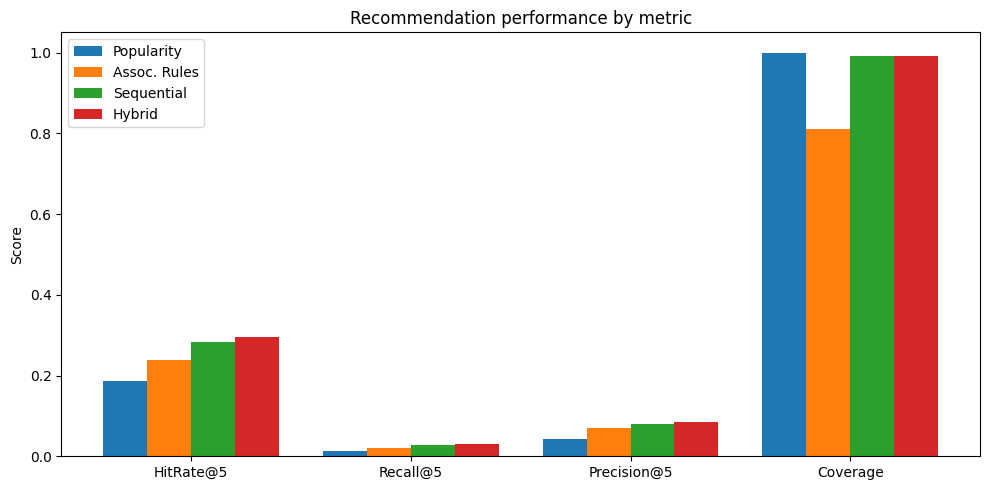

In [ ]:
plot_df = comparison_df.copy()
plot_df["method"] = ["Popularity", "Assoc. Rules", "Sequential", "Hybrid"]

metrics = ["HitRate@5", "Recall@5", "Precision@5", "Coverage"]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(10, 5))

for i, method in enumerate(plot_df["method"]):
    plt.bar(
        x + (i - 1.5) * width,
        plot_df.loc[plot_df["method"] == method, metrics].values[0],
        width=width,
        label=method
    )

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Recommendation performance by metric")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

### Results and Interpretation

From the full comparison, we could see that the **hybrid sequential-plus-embedding recommender** performed best overall, with the highest Hit Rate, Recall, and Precision while keeping the same very high coverage as the original sequential recommender. The **sequential recommender** performed second best, which shows that purchase order adds useful predictive information beyond unordered basket structure. The **association-rule recommender** performed third, improving on the popularity baseline by using co-purchase structure within baskets. The **popularity baseline** remained the weakest method because it recommends the same globally common items to nearly everyone.

This comparison gives a strong answer to the main project question. Basket structure does improve next-basket recommendation beyond simple popularity, but **time-ordered purchase structure improves it further**. The hybrid extension adds one more useful result to show that embedding similarity can help, but only when it is used to strengthen the sequential recommender. On its own, embedding-based ranking was not strong enough. In this dataset, the most useful signal comes from explicit basket rules and next-basket transitions, with embeddings providing a modest but real improvement when they are layered on top of sequential structure.

### Validate the Final Comparison

Before moving to the conclusion, we run a small check to confirm that the comparison table includes the expected methods and metrics.

In [ ]:
def test_comparison_table(comparison_df: pd.DataFrame):
    expected_methods = {
        "Popularity Baseline",
        "Association-Rule Recommender",
        "Sequential Recommender",
        "Hybrid Sequential + Embedding",
    }
    assert set(comparison_df["method"]) == expected_methods

    expected_cols = {"HitRate@5", "Recall@5", "Precision@5", "Coverage", "n_test_customers"}
    assert expected_cols.issubset(comparison_df.columns)

    assert (comparison_df["Coverage"] >= 0).all() and (comparison_df["Coverage"] <= 1).all()
    assert (comparison_df["HitRate@5"] >= 0).all() and (comparison_df["HitRate@5"] <= 1).all()

    print("Comparison table checks passed.")


test_comparison_table(comparison_df)

Comparison table checks passed.


## Final Conclusion and Discussion

For this project, we studied whether time-ordered purchase patterns improve next-basket recommendation beyond simpler basket-based methods. We compared four recommenders on the same last-basket holdout task: a global popularity baseline, an association-rule recommender, a sequential recommender, and a hybrid sequential-plus-embedding recommender.

### Main Answer

The main answer of this project is **yes**: time-ordered purchase patterns improve next-basket recommendation beyond both a popularity-based baseline and an unordered basket-based association-rule recommender.

More specifically:
- **Popularity alone** provides broad coverage but weak personalization.
- **Association rules** improve recommendation by using co-purchase structure within baskets.
- **Sequential patterns** improve recommendation further, which shows that purchase order adds meaningful information beyond unordered basket structure.
- **Hybrid sequential + embedding reranking** performs best overall, which suggests that embeddings are useful when they strengthen a time-ordered recommender rather than replace its explicit sequential structure.

This means the strongest evidence in the notebook points to **interpretable rule-based structure**, especially when that structure includes time order, with embeddings providing a smaller supporting role.

### What the Extension Adds

The embedding-based extension helped test whether a learned item representation could improve recommendation beyond explicit rule-based methods. The answer is **yes**, but only in a limited way. When embeddings were used alone for ranking, they were not competitive with the rule-based recommenders. When they were used to rerank sequential candidates, they produced a small but consistent improvement over the sequential recommender.

This strengthens the overall story of the notebook. It suggests that the core predictive signal in this dataset comes from explicit basket and next-basket patterns, while embeddings are most useful when they refine those patterns rather than replace them.

### Limitations

This project also has some limitations. First, for the sequential recommender, we used short item-to-item transitions between consecutive baskets rather than richer or longer sequential structures. Second, we built the association-rule and sequential recommenders from relatively simple and interpretable rules, which helps explain the results, but on the other hand, may leave some predictive power unused. Third, in the hybrid extension, we used basket-level item embeddings and a simple reranking strategy, so it should be viewed as a lightweight enhancement rather than a fully optimized representation-learning approach. Finally, we used a last-basket holdout setup for evaluation. While it is appropriate for this project, it still captures only one form of future prediction.

### Future Work

There are several natural ways to extend this project. We could use richer sequential methods, such as longer PrefixSpan-style patterns or more structured next-basket sequence rules. We could also compare different recommendation cutoffs and rule-ranking strategies more systematically. Finally, we could test stronger embedding or neural recommendation methods using the same evaluation setup.

Even with these possible extensions, the core finding of the notebook is already clear. Time-ordered purchase behavior improves next-basket recommendation, and embeddings are most useful when they support a strong sequential recommender rather than replace explicit purchase-pattern structure.

## Resources
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://archive.ics.uci.edu/dataset/352/online+retail: Online Retail Dataset

3. AI Tools:
- ChatGPT: I first used ChatGPT to discuss my final project ideas as long as I came up with one. It helped me to narrow them down, and I eventually chose the idea in this notebook as the main direction. After that, I used it to help plan the project in more detail, including the overall workflow and implementation steps. Based on that plan, I prompted it to generate code for different parts of the notebook, and I reviewed the outputs carefully to make sure the code matched what I wanted and ran correctly. I also used ChatGPT to help revise and polish my write-ups so they were clearer, more professional, and more fluent.

In [64]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
!python --version

Python 3.12.13
